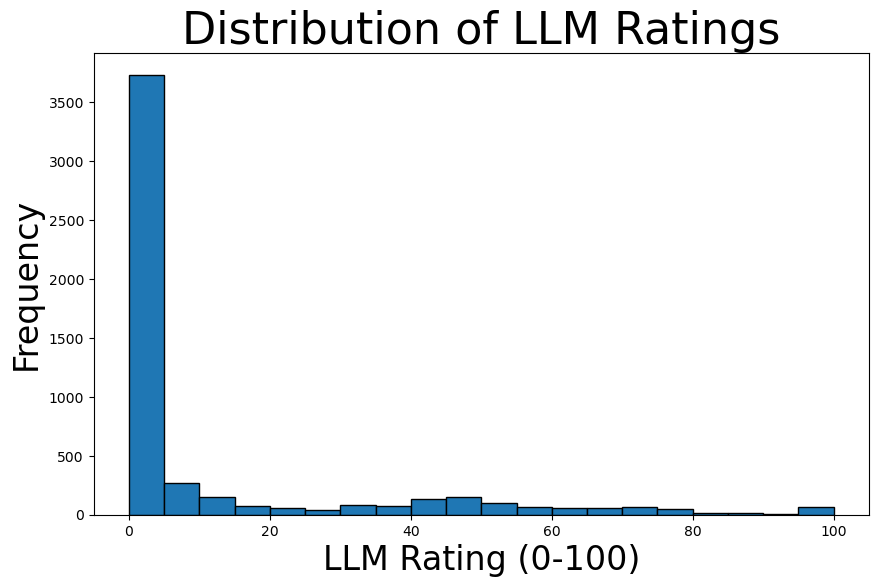

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the CSV file
df = pd.read_csv("../data/tmdb_movies_with_llm_rating.csv")

# Visualize the 'llm rating' column with a histogram
plt.figure(figsize=(10, 6))
plt.hist(df["overview_rating"], bins=20, edgecolor="black")
plt.title("Distribution of LLM Ratings", fontsize=32)
plt.xlabel("LLM Rating (0-100)", fontsize=24)
plt.ylabel("Frequency", fontsize=24)
plt.savefig("../results/llm_rating_histogram.png")  # Save the figure as a PNG file
plt.show()

                      roi  vote_average  overview_rating
roi              1.000000      0.189476         0.241296
vote_average     0.189476      1.000000         0.108052
overview_rating  0.241296      0.108052         1.000000


/opt/anaconda3/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


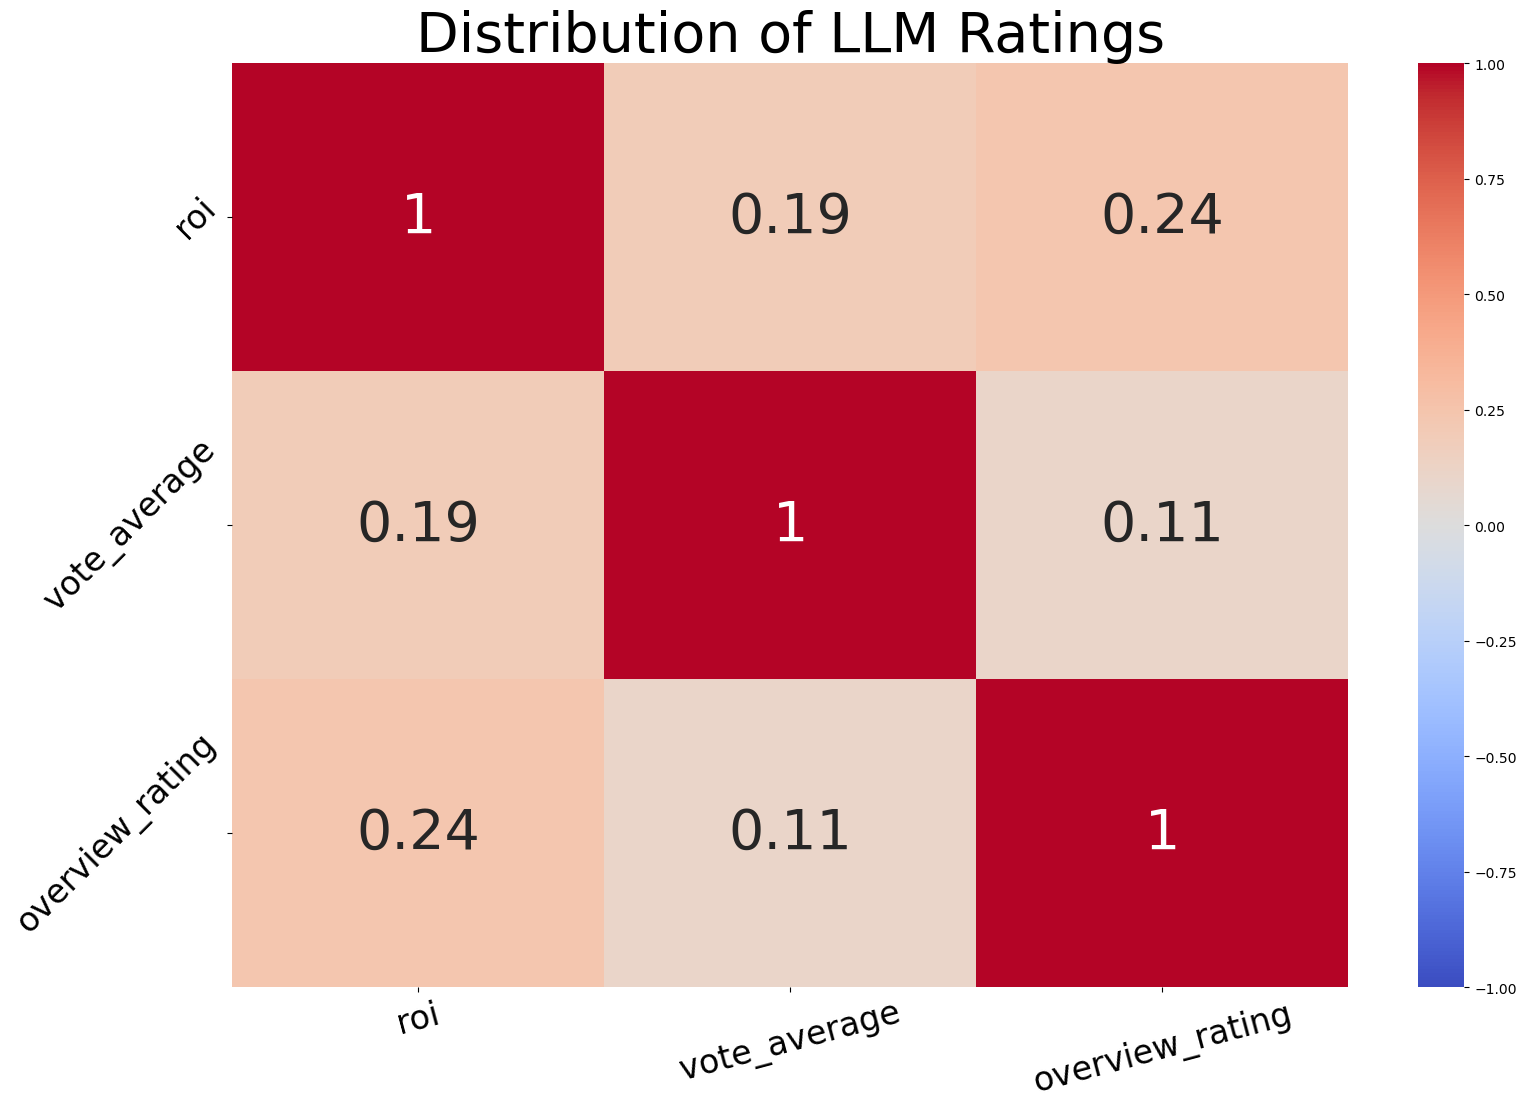

In [62]:
import seaborn as sns


df["roi"] = (df["revenue"] / df["budget"]).clip(upper=10)
df["success"] = (df["roi"] > 2).astype(int)
df["roi_log"] = np.log1p(df["roi"])
correlation_matrix = df[["roi", "vote_average", "overview_rating"]].corr()


print(correlation_matrix)


plt.figure(figsize=(18, 12))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    annot_kws={"size": 40},
)
plt.title("Correlation: ROI, LLM Rating, and Vote Average")
plt.xticks(fontsize=24, rotation=15)
plt.yticks(fontsize=24, rotation=45)
plt.title("Distribution of LLM Ratings", fontsize=40)
plt.savefig(
    "../results/correlation_matrix_heatmap.png"
)  # Save the figure as a PNG file
plt.show()